<a href="https://colab.research.google.com/github/dea43325108-crypto/Visi-Komputer_Dea-Cantika/blob/main/Jobsheet02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Praktikum D1 - Memulai Klasifikasi Gambar dengan Dataset Sederhana**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


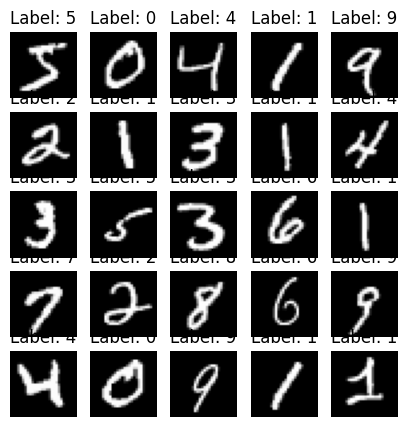

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

**Praktikum D2 - Klasifikasi Gambar dengan Model Machine Learning Tradisional**

In [10]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM
clf = svm.SVC(kernel='rbf', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) # gunakan subset karena SVM berat
y_pred = clf.predict(x_test_flat)

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9513


**Praktikum D3 – Membangun CNN Sederhana**

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 33ms/step - accuracy: 0.9602 - loss: 0.1321 - val_accuracy: 0.9888 - val_loss: 0.0455
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9866 - loss: 0.0423 - val_accuracy: 0.9885 - val_loss: 0.0414
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 34ms/step - accuracy: 0.9912 - loss: 0.0280 - val_accuracy: 0.9908 - val_loss: 0.0352
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - accuracy: 0.9934 - loss: 0.0204 - val_accuracy: 0.9885 - val_loss: 0.0386
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9950 - loss: 0.0153 - val_accuracy: 0.9912 - val_loss: 0.0364


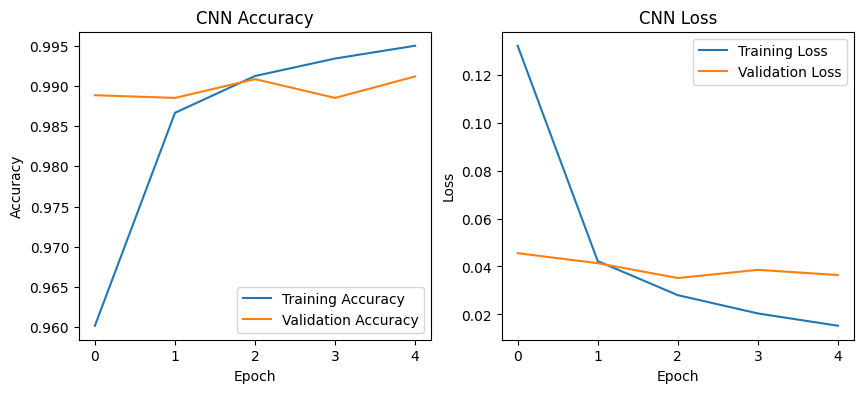

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

x_train_cnn = x_train.reshape(-1,28,28,1) / 255.0
x_test_cnn = x_test.reshape(-1,28,28,1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

**Praktikum D4 – Eksperimen dengan Dataset Lebih Kompleks (CIFAR-10)**

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 43ms/step - accuracy: 0.3312 - loss: 1.7852 - val_accuracy: 0.4916 - val_loss: 1.4218
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 40ms/step - accuracy: 0.4308 - loss: 1.5303 - val_accuracy: 0.5656 - val_loss: 1.2245
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 41ms/step - accuracy: 0.4795 - loss: 1.4169 - val_accuracy: 0.5884 - val_loss: 1.2053
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.5122 - loss: 1.3414 - val_accuracy: 0.5974 - val_loss: 1.1543
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 41ms/step - accuracy: 0.5429 - loss: 1.2682 - val_accuracy: 0.6332 - val_loss: 1.0471
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.5636 - loss: 1.2126 - val_accuracy: 0.6364 - val_loss: 1.0309
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.5826 - loss: 1.1661 - val_accuracy: 0.6616 - val_loss: 0.9762
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 40ms/step - accuracy: 0.6003 -

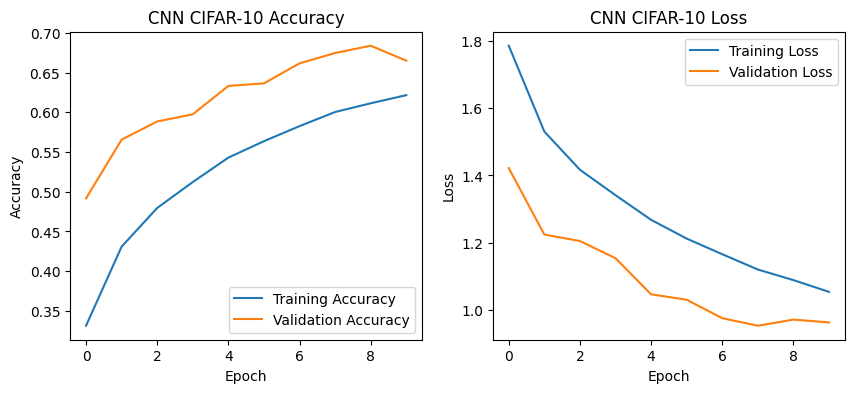

In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

**Praktikum D5 – Transfer Learning dengan Model Pra-Latih**

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 31s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 758s 538ms/step - accuracy: 0.5657 - loss: 1.2413 - val_accuracy: 0.6192 - val_loss: 1.0778
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 746s 531ms/step - accuracy: 0.6352 - loss: 1.0422 - val_accuracy: 0.6506 - val_loss: 0.9943
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 747s 531ms/step - accuracy: 0.6578 - loss: 0.9737 - val_accuracy: 0.6546 - val_loss: 0.9958
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 758s 539ms/step - accuracy: 0.6754 - loss: 0.9243 - val_accuracy: 0.6624 - val_loss: 0.9664
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 732s 520ms/step - accuracy: 0.6895 - loss: 0.8810 - val_accuracy: 0.6626 - val_loss: 0.9783


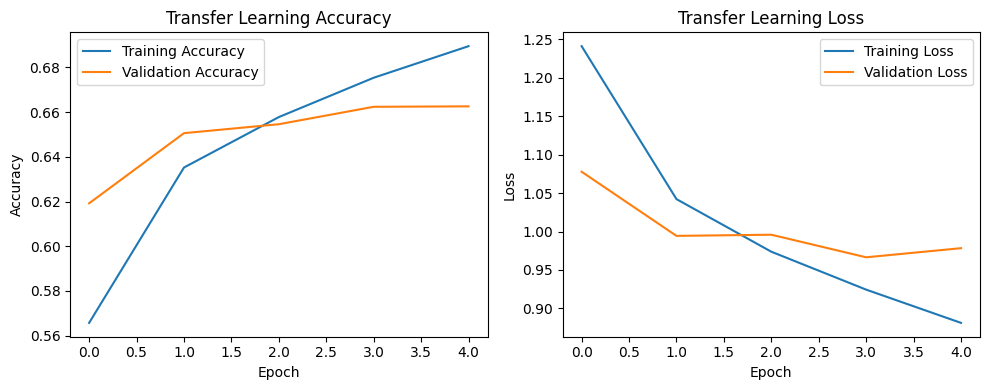

In [ ]:
# 1. Import semua pustaka yang dibutuhkan
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.datasets import cifar10

# 2. Load dan siapkan dataset CIFAR-10 (Solusi agar tidak error 'x_train_c')
(x_train_c, y_train_c), (x_test_c, y_test_c) = cifar10.load_data()
x_train_c, x_test_c = x_train_c/255.0, x_test_c/255.0

# 3. Load model bawaan VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# 4. Jawaban Tugas Kecil: Fine-tuning 2 layer terakhir
base_model.trainable = True
for layer in base_model.layers[:-2]:
    layer.trainable = False

# 5. Bangun model utama
model_d5 = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 6. Compile model
model_d5.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# 7. Latih model
history_d5 = model_d5.fit(x_train_c, y_train_c, epochs=5, validation_split=0.1)

# 8. Plot grafik akurasi dan loss
plt.figure(figsize=(10,4))

# Grafik Akurasi
plt.subplot(1,2,1)
plt.plot(history_d5.history['accuracy'], label='Training Accuracy')
plt.plot(history_d5.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Grafik Loss
plt.subplot(1,2,2)
plt.plot(history_d5.history['loss'], label='Training Loss')
plt.plot(history_d5.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Praktikum D6 – Evaluasi dengan Confusion Matrix dan Metrik Lain**

313/313 ━━━━━━━━━━━━━━━━━━━━ 132s 417ms/step
              precision    recall  f1-score   support

           0       0.79      0.64      0.71      1000
           1       0.84      0.66      0.74      1000
           2       0.55      0.63      0.59      1000
           3       0.48      0.55      0.51      1000
           4       0.57      0.66      0.61      1000
           5       0.72      0.36      0.48      1000
           6       0.72      0.71      0.71      1000
           7       0.65      0.77      0.70      1000
           8       0.74      0.82      0.77      1000
           9       0.66      0.78      0.71      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.65     10000
weighted avg       0.67      0.66      0.65     10000



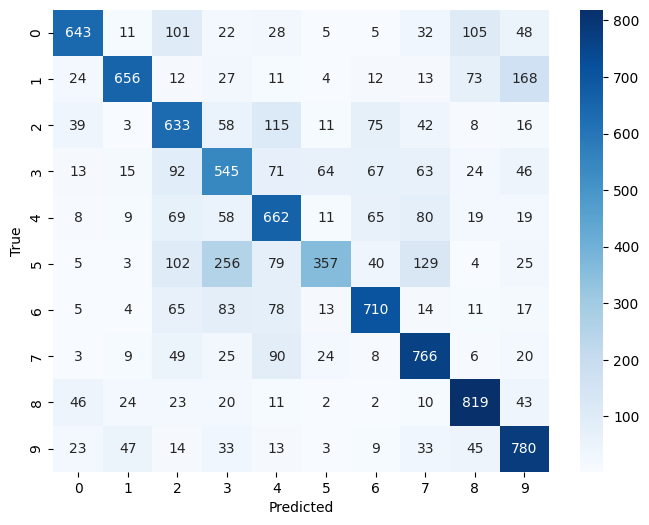

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Menggunakan model D5 dan data uji CIFAR-10 (x_test_c & y_test_c)
y_pred = model_d5.predict(x_test_c).argmax(axis=1)

# Tampilkan Laporan Klasifikasi (Precision, Recall, F1-Score)
print(classification_report(y_test_c, y_pred))

# Tampilkan Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

**Penugasan - Mencoba klasifikasi tulisan angka**

In [3]:
# ===== 1) Upload file foto tulisan angka =====
from google.colab import files
uploaded = files.upload() # pilih 1 atau lebih file gambar (jpg/png)

# ===== 2) Utilitas Preprocess agar mirip MNIST (28x28, putih-di-atas-hitam) =====
import numpy as np
from PIL import Image, ImageOps

def preprocess_to_mnist_28x28(img_pil):
    """
    Langkah:
    - Konversi ke grayscale
    - Auto-contrast
    - (Opsional) invert bila latar terang (agar digit jadi putih, latar
    jadi gelap seperti MNIST)
    - Crop ke bounding box digit
    - Resize mempertahankan rasio ke (20x20), lalu pad ke (28x28)
    - Normalisasi ke [0,1] dan tambah axis channel
    """
    # Grayscale + autocontrast
    img = img_pil.convert('L')
    img = ImageOps.autocontrast(img)

    arr = np.array(img).astype(np.uint8)
    # Jika rata-rata terang (kertas putih), invert supaya digit menjadi
    # putih di atas latar gelap (gaya MNIST)
    if arr.mean() > 127:
        img = ImageOps.invert(img)
        arr = np.array(img)

    # Binarisasi ringan untuk cari bbox digit
    thr = np.mean(arr) * 0.8 # ambang adaptif sederhana
    mask = arr > thr
    if mask.any():
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()
        img = img.crop((x0, y0, x1+1, y1+1))

    # Resize ke 20x20 dengan aspect ratio
    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    w, h = img.size

    # Pad ke 28x28 dan center
    canvas = Image.new('L', (28, 28), color=0)
    canvas.paste(img, ((28 - w)//2, (28 - h)//2))

    # Normalisasi ke [0,1]
    arr = np.array(canvas).astype('float32') / 255.0
    # Tambah channel dim (28,28,1)
    arr = arr[..., None]
    return canvas, arr

Saving 2.jpg to 2 (2).jpg
Saving 5.jpg to 5 (1).jpg
Saving 6.jpg to 6 (1).jpg


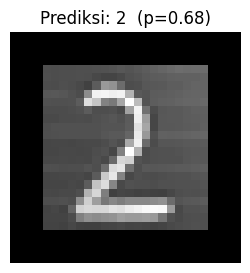

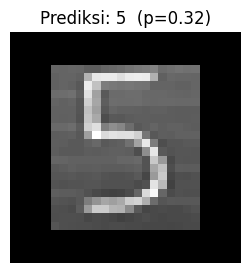

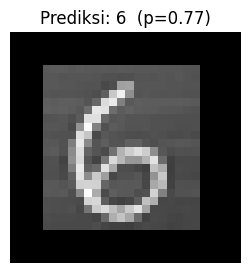

Rekap Prediksi (CNN):
- 2 (2).jpg -> 2  (p=0.680)
- 5 (1).jpg -> 5  (p=0.320)
- 6 (1).jpg -> 6  (p=0.772)


In [9]:
import matplotlib.pyplot as plt

results = []
for fname in uploaded.keys():
    img_pil = Image.open(fname)
    disp, x = preprocess_to_mnist_28x28(img_pil)  # disp: PIL untuk ditampilkan, x: (28,28,1)
    x_batch = np.expand_dims(x, axis=0)           # (1,28,28,1)
    probs = model.predict(x_batch, verbose=0)[0]  # shape (10,)
    pred = int(np.argmax(probs))
    conf = float(np.max(probs))

    results.append((fname, pred, conf))

    # Tampilkan hasil
    plt.figure(figsize=(3,3))
    plt.imshow(disp, cmap='gray')
    plt.title(f"Prediksi: {pred}  (p={conf:.2f})")
    plt.axis('off')
    plt.show()

# Rekap ringkas
print("Rekap Prediksi (CNN):")
for r in results:
    print(f"- {r[0]} -> {r[1]}  (p={r[2]:.3f})")

In [11]:
from sklearn.metrics import accuracy_score

results = []
for fname in uploaded.keys():
    img_pil = Image.open(fname)
    _, x = preprocess_to_mnist_28x28(img_pil)     # x: (28,28,1) float [0,1]
    x_flat = x.reshape(1, -1)                     # (1,784)

    pred = int(clf.predict(x_flat)[0])

    # SVM default tidak punya proba kecuali SVC(probability=True). Jika
    # Anda ingin probabilitas:
    # clf = svm.SVC(kernel='rbf', gamma='scale', probability=True) saat
    # pelatihan.
    conf = None
    try:
        if hasattr(clf, "predict_proba"):
            conf = float(np.max(clf.predict_proba(x_flat)))
    except Exception:
        pass

    results.append((fname, pred, conf))

    # Tampilkan hasil (gunakan gambar 28x28 yang sudah diproses di tahap
    # CNN juga boleh)
    print(f"{fname} -> Prediksi SVM: {pred}" + (f"  (p={conf:.2f})" if conf is not None else ""))

2 (2).jpg -> Prediksi SVM: 8
5 (1).jpg -> Prediksi SVM: 8
6 (1).jpg -> Prediksi SVM: 8
